# Tarea 2 -- Modelo de propension: em_acount

easyMoney - TFM Nuclio Digital School

Segundo modelo de propension, sobre `em_acount` (producto secundario de alto valor). Mismo enfoque metodologico que `03_modelling_pension_plan.ipynb`, aplicado a un producto distinto para comprobar que el metodo generaliza. Parte del panel guardado por `02_preprocessing_propension.ipynb`.

Una diferencia respecto al notebook de `pension_plan`: aqui SI incluimos `pension_plan_lag1` como feature (ya no es una columna constante para este modelo, y puede aportar senal: si ya tiene `pension_plan`, puede predecir su interes por `em_acount`). La columna que ahora se convierte en constante (y por tanto se excluye como feature) es `em_acount_lag1`, que usamos solo para filtrar el universo elegible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

df_panel = pd.read_parquet('data/df_panel_propension.parquet', engine='pyarrow')
print(df_panel.shape)

(5961849, 35)


## 1. Target: adquisicion nueva de em_acount

In [2]:
df_panel['target_em_acount'] = df_panel.groupby('pk_cid')['em_acount'].diff()
df_panel['target_em_acount'] = df_panel['target_em_acount'].apply(lambda x: 1 if x == 1 else 0)

print(df_panel['target_em_acount'].value_counts())

target_em_acount
0    5920923
1      40926
Name: count, dtype: int64


## 2. Universo elegible

Filtramos a clientes que el mes anterior NO tenian `em_acount`. `em_acount` es un producto mucho mas extendido que `pension_plan`, asi que el universo elegible es bastante mas pequeno (menos clientes 'sin el producto'), pero el desbalanceo del target es mas suave.

In [3]:
features_base = ['age', 'salary', 'gender', 'segment', 'entry_channel',
                  'active_customer', 'num_products']
lag_cols_necesarias = [f'{c}_lag1' for c in features_base] + ['em_acount_lag1', 'pension_plan_lag1']

df_model_em = df_panel.dropna(subset=lag_cols_necesarias).copy()
df_model_em = df_model_em[df_model_em['em_acount_lag1'] == 0].copy()

print('Filas tras filtrar elegibles (em_acount):', df_model_em.shape)
print(df_model_em['target_em_acount'].value_counts())

Filas tras filtrar elegibles (em_acount): (1421026, 36)
target_em_acount
0    1380100
1      40926
Name: count, dtype: int64


## 3. Split temporal (train / test / validacion)

In [4]:
meses = sorted(df_model_em['pk_partition'].unique())
mes_val = meses[-1]
mes_test = meses[-2]
print('Mes de test:', mes_test, '| Mes de validacion:', mes_val)

train_em = df_model_em[df_model_em['pk_partition'] < mes_test]
test_em  = df_model_em[df_model_em['pk_partition'] == mes_test]
val_em   = df_model_em[df_model_em['pk_partition'] == mes_val]

print('Train:', train_em.shape)
print('Test: ', test_em.shape)
print('Val:  ', val_em.shape)

Mes de test: 2019-04-01 00:00:00 | Mes de validacion: 2019-05-01 00:00:00
Train: (1138456, 36)
Test:  (139972, 36)
Val:   (142598, 36)


## 4. Codificacion de variables

Agrupamos `entry_channel` raras calculando la frecuencia SOLO con `train_em` (no reciclamos el calculo del notebook de `pension_plan`, porque el universo de filas es distinto).

In [5]:
frecuencias_em = train_em['entry_channel_lag1'].value_counts(normalize=True)
categorias_frecuentes_em = frecuencias_em[frecuencias_em >= 0.01].index

def agrupar_entry_channel_em(serie):
    return serie.where(serie.isin(categorias_frecuentes_em), 'Otros')

train_em = train_em.copy()
test_em = test_em.copy()
val_em = val_em.copy()
train_em['entry_channel_lag1'] = agrupar_entry_channel_em(train_em['entry_channel_lag1'])
test_em['entry_channel_lag1']  = agrupar_entry_channel_em(test_em['entry_channel_lag1'])
val_em['entry_channel_lag1']   = agrupar_entry_channel_em(val_em['entry_channel_lag1'])

print('Categorias tras agrupar:', train_em['entry_channel_lag1'].nunique())

cat_cols_em = ['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
num_cols_em = ['age_lag1', 'salary_lag1', 'active_customer_lag1', 'num_products_lag1', 'pension_plan_lag1']

X_train_em = pd.get_dummies(train_em[num_cols_em + cat_cols_em], columns=cat_cols_em)
X_test_em  = pd.get_dummies(test_em[num_cols_em + cat_cols_em], columns=cat_cols_em)
X_val_em   = pd.get_dummies(val_em[num_cols_em + cat_cols_em], columns=cat_cols_em)

X_test_em = X_test_em.reindex(columns=X_train_em.columns, fill_value=0)
X_val_em  = X_val_em.reindex(columns=X_train_em.columns, fill_value=0)

y_train_em = train_em['target_em_acount']
y_test_em  = test_em['target_em_acount']
y_val_em   = val_em['target_em_acount']

print('X_train_em:', X_train_em.shape)
print('X_test_em: ', X_test_em.shape)
print('X_val_em:  ', X_val_em.shape)

Categorias tras agrupar: 12
X_train_em: (1138456, 23)
X_test_em:  (139972, 23)
X_val_em:   (142598, 23)


## 5. Modelo

In [6]:
modelo_em = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
modelo_em.fit(X_train_em, y_train_em)
print('Modelo entrenado correctamente.')

Modelo entrenado correctamente.


## 6. Evaluacion tecnica (sobre el mes de test)

              precision    recall  f1-score   support

   No compra       1.00      0.81      0.89    137392
      Compra       0.07      0.80      0.13      2580

    accuracy                           0.81    139972
   macro avg       0.53      0.80      0.51    139972
weighted avg       0.98      0.81      0.88    139972



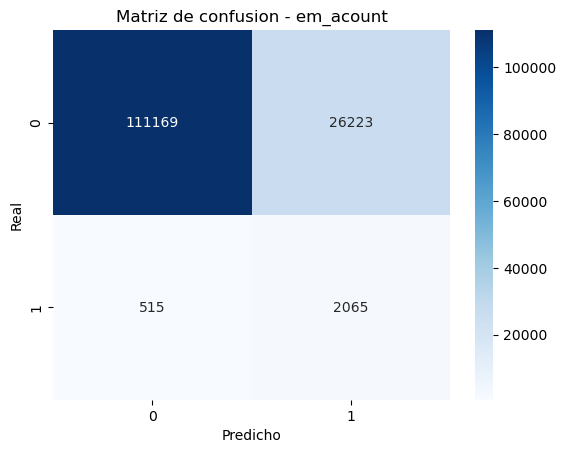

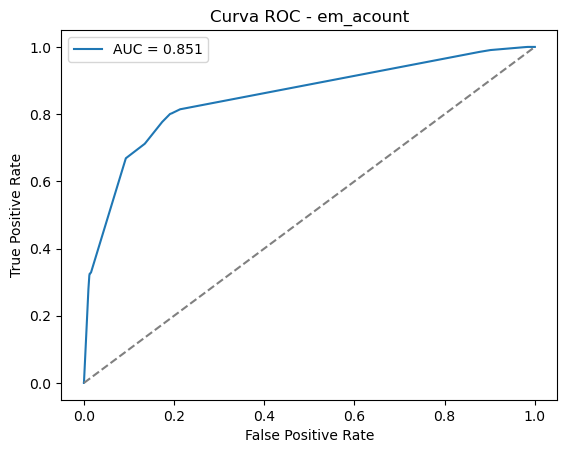

In [7]:
y_pred_em = modelo_em.predict(X_test_em)
y_proba_em = modelo_em.predict_proba(X_test_em)[:, 1]

print(classification_report(y_test_em, y_pred_em, target_names=['No compra', 'Compra']))

cm_em = confusion_matrix(y_test_em, y_pred_em)
sns.heatmap(cm_em, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusion - em_acount')
plt.show()

fpr_em, tpr_em, _ = roc_curve(y_test_em, y_proba_em)
roc_auc_em = auc(fpr_em, tpr_em)
plt.plot(fpr_em, tpr_em, label=f'AUC = {roc_auc_em:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - em_acount')
plt.legend()
plt.show()

## 7. Evaluacion de negocio: conversion real en el top 5%

In [8]:
val_proba_em = modelo_em.predict_proba(X_val_em)[:, 1]

df_sim_em = pd.DataFrame({
    'pk_cid': val_em['pk_cid'].values,
    'probabilidad': val_proba_em,
    'compra_real': y_val_em.values
}).sort_values(by='probabilidad', ascending=False)

top_pct = 0.05
top_n_em = int(len(df_sim_em) * top_pct)
top_clientes_em = df_sim_em.head(top_n_em)

compras_en_top_em = top_clientes_em['compra_real'].sum()
tasa_conversion_top_em = compras_en_top_em / top_n_em
tasa_base_em = df_sim_em['compra_real'].mean()

print(f'Clientes evaluados en validacion: {len(df_sim_em)}')
print(f'Clientes en el top {top_pct*100:.0f}%: {top_n_em}')
print(f'Compras reales dentro del top: {compras_en_top_em}')
print(f'Tasa de conversion en el top {top_pct*100:.0f}%: {tasa_conversion_top_em*100:.2f}%')
print(f'Tasa de conversion si contactases al azar: {tasa_base_em*100:.2f}%')
print(f'El modelo mejora la conversion x{tasa_conversion_top_em/tasa_base_em:.1f} frente a contactar al azar')

Clientes evaluados en validacion: 142598
Clientes en el top 5%: 7129
Compras reales dentro del top: 1128
Tasa de conversion en el top 5%: 15.82%
Tasa de conversion si contactases al azar: 1.73%
El modelo mejora la conversion x9.1 frente a contactar al azar


## Resumen de resultados (em_acount)

- AUC (test): 0.851
- Recall clase Compra (test): 0.80
- Precision clase Compra (test): 0.07 (mejor que en pension_plan, porque el desbalanceo es menos extremo)
- Conversion real en el top 5% (validacion): 15.82%, frente a 1.73% al azar -> x9.1
- El top 5% (7.129 clientes) captura 1.128 de los compradores reales de mayo 2019 (~46% de todos los compradores reales, contactando solo al 5% de la base).

## Comparativa con pension_plan

| Metrica | pension_plan | em_acount |
|---|---|---|
| AUC | 0.862 | 0.851 |
| Recall (test) | 0.87 | 0.80 |
| Conversion top 5% | 4.15% | 15.82% |
| Mejora vs. azar | x6.3 | x9.1 |

El metodo (target por diff, features lag-1, split temporal, class_weight balanced) generaliza bien a dos productos con perfiles de desbalanceo muy distintos.

## 8. Scoring final: clientes reales a contactar hoy

Todo lo anterior evaluaba el modelo contra meses ya conocidos. Aquí lo aplicamos
de verdad: cogemos el estado de cada cliente en el último mes disponible y
predecimos su propensión para el mes siguiente (uno que todavía no ha pasado).

In [11]:
ultimo_mes_em = df_model_em['pk_partition'].max()
df_actual_em = df_panel[df_panel['pk_partition'] == ultimo_mes_em].copy()

df_actual_em = df_actual_em[df_actual_em['em_acount'] == 0].copy()

df_actual_em['entry_channel'] = df_actual_em['entry_channel'].where(
    df_actual_em['entry_channel'].isin(categorias_frecuentes_em), 'Otros'
)

X_actual_em = pd.get_dummies(
    df_actual_em[['age', 'salary', 'active_customer', 'num_products', 'pension_plan',
                  'gender', 'segment', 'entry_channel']]
    .rename(columns={
        'age': 'age_lag1', 'salary': 'salary_lag1',
        'active_customer': 'active_customer_lag1', 'num_products': 'num_products_lag1',
        'pension_plan': 'pension_plan_lag1',
        'gender': 'gender_lag1', 'segment': 'segment_lag1', 'entry_channel': 'entry_channel_lag1'
    }),
    columns=['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
)
X_actual_em = X_actual_em.reindex(columns=X_train_em.columns, fill_value=0)

proba_actual_em = modelo_em.predict_proba(X_actual_em)[:, 1]

df_scoring_em = pd.DataFrame({
    'pk_cid': df_actual_em['pk_cid'].values,
    'probabilidad_em_acount': proba_actual_em
}).sort_values(by='probabilidad_em_acount', ascending=False).reset_index(drop=True)

print(f'Clientes elegibles para em_acount hoy: {len(df_scoring_em)}')
print(df_scoring_em.head(1000))

df_scoring_em.to_csv('data/scoring_em_acount.csv', index=False)
print('Guardado en data/scoring_em_acount.csv')

Clientes elegibles para em_acount hoy: 146575
      pk_cid  probabilidad_em_acount
0    1553689                 0.95111
1    1551974                 0.95111
2    1549400                 0.95111
3    1551994                 0.95111
4    1549405                 0.95111
..       ...                     ...
995  1550459                 0.95111
996  1550417                 0.95111
997  1550457                 0.95111
998  1550343                 0.95111
999  1550451                 0.95111

[1000 rows x 2 columns]
Guardado en data/scoring_em_acount.csv


In [12]:
df = pd.read_csv('/Users/sandramartinez/Desktop/Proyectos_Data/TFM-EasyMoney/grupo-1-dscesp-0226/Notebooks/data/scoring_pension_plan.csv')

In [19]:
pd.set_option('display.max_rows', None)